<div class="alert alert-block alert-info">
    <b>Tip:</b> Use blue boxes (alert-info) for tips and notes. 
    If it’s a note, you don’t have to include the word “Note”.
</div>

# 1. Importar librerias

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from os.path import basename

In [45]:
def relative_path():
    path = '.'
    path = os.path.realpath('.')
    return path[:-len(basename(path))]

path = os.path.join(relative_path(), 'data\\raw\\2023-03-08 Precios Casas RM.csv')

## 1.1 Carga y copia del dataset

In [46]:
data = pd.read_csv(path)
data = data.copy()

# 2. Exploracion inicial

In [47]:
data.head()

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor
0,409285000,11500,509695,QuintaNormal,Hoevel4548y4558,7,4.0,384.0,732.0,3.0,11700213,NaN
1,105000000,2950,130760,PedroAguirreCerda,Rucalhue,2,1.0,112.0,145.0,1.0,10894299,Legales y Propiedades SpA
2,128124000,3600,159557,EstaciónCentral,AvenidaLasParcelas,3,1.0,59.0,243.0,2.0,10257635,Propiedadesrs
3,75000000,2107,93400,Colina,PasajeGonzaloRojas,3,1.0,103.0,73.0,1.0,9232092,Patricio Gajardo propiedades
4,53000000,1489,66002,Colina,HernánDíazArrieta2820,2,1.0,57.0,67.0,1.0,7085397,Patricio Gajardo propiedades


In [51]:
data.drop(columns=['Realtor', 'Comuna', 'Ubicacion']).head().style.format("{:,.2f}")

,Price_CLP,Price_UF,Price_USD,Dorms,Baths,Built Area,Total Area,Parking,id
0,"409,285,000.00","11,500.00","509,695.00",7.00,4.00,384.00,732.00,3.00,"11,700,213.00"
1,"105,000,000.00","2,950.00","130,760.00",2.00,1.00,112.00,145.00,1.00,"10,894,299.00"
2,"128,124,000.00","3,600.00","159,557.00",3.00,1.00,59.00,243.00,2.00,"10,257,635.00"
3,"75,000,000.00","2,107.00","93,400.00",3.00,1.00,103.00,73.00,1.00,"9,232,092.00"
4,"53,000,000.00","1,489.00","66,002.00",2.00,1.00,57.00,67.00,1.00,"7,085,397.00"


In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7779 entries, 0 to 7778
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Price_CLP   7779 non-null   int64  
 1   Price_UF    7779 non-null   int64  
 2   Price_USD   7779 non-null   int64  
 3   Comuna      7779 non-null   object 
 4   Ubicacion   7779 non-null   object 
 5   Dorms       7779 non-null   int64  
 6   Baths       7714 non-null   float64
 7   Built Area  7533 non-null   float64
 8   Total Area  7571 non-null   float64
 9   Parking     5489 non-null   float64
 10  id          7779 non-null   int64  
 11  Realtor     7184 non-null   object 
dtypes: float64(4), int64(5), object(3)
memory usage: 729.4+ KB


In [49]:
data.describe().style.format("{:,.2f}")

,Price_CLP,Price_UF,Price_USD,Dorms,Baths,Built Area,Total Area,Parking,id
count,"7,779.00","7,779.00","7,779.00","7,779.00","7,714.00","7,533.00","7,571.00","5,489.00","7,779.00"
mean,"364,248,117.63","10,234.57","453,609.11",3.99,2.65,229.92,807.92,2.98,"9,910,827.69"
std,"386,880,986.22","10,870.49","481,794.50",1.62,1.47,"1,676.90","9,050.89",17.75,"2,046,316.67"
min,"2,085.00",0.00,3.00,1.00,1.00,1.00,1.00,1.00,"1,213,620.00"
25%,"120,000,000.00","3,372.00","149,440.00",3.00,2.00,85.00,129.50,1.00,"8,563,078.50"
50%,"205,000,000.00","5,760.00","255,293.00",4.00,2.00,128.00,210.00,2.00,"10,548,072.00"
75%,"491,142,000.00","13,800.00","611,634.00",5.00,3.00,200.00,443.00,3.00,"11,524,632.00"
max,"5,516,450,000.00","155,000.00","6,869,801.00",27.00,29.00,"120,000.00","678,000.00","1,269.00","12,341,490.00"


In [50]:
data.isnull().sum()

Price_CLP        0
Price_UF         0
Price_USD        0
Comuna           0
Ubicacion        0
Dorms            0
Baths           65
Built Area     246
Total Area     208
Parking       2290
id               0
Realtor        595
dtype: int64

# 3. Limpieza de nulos

In [52]:
cols = ['Baths', 'Built Area', 'Total Area', 'Parking', 'Realtor']
for col in cols:
    print(f'% de datos que son nulos para "{col}": { ( ( data[col].isnull().sum() / data.shape[0] ) * 100 ).round(2) }%')


% de datos que son nulos para "Baths": 0.84%
% de datos que son nulos para "Built Area": 3.16%
% de datos que son nulos para "Total Area": 2.67%
% de datos que son nulos para "Parking": 29.44%
% de datos que son nulos para "Realtor": 7.65%


<div class="alert alert-block alert-info">
    Baths, Built Area y Total Area seran eliminadas, ya que su porcentaje de datos nulos que seran eliminados son muy pequeños.<br>
    Es ruido cuando el porcentaje es < a 5% 
</div>

In [67]:
data_clean = data.dropna(subset=['Baths', 'Built Area', 'Total Area'])

In [68]:
print(data_clean.shape, data.shape)

(7467, 12) (7779, 12)


In [79]:
# Regla:
# Outlier si x < Q1 - 1.5*IQR o x > Q3 + 1.5*IQR

def detectar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    mascara = (serie < limite_inferior) | (serie > limite_superior)

    return mascara, limite_inferior, limite_superior

data_check = data_clean.drop(columns=['Comuna', 'Ubicacion', 'Realtor', 'id'])
outlier_mask = pd.Series(False, index=data_clean.index)

for name in data_check:
    mask_iqr, li, ls = detectar_outliers_iqr(data_check[name])
    print(f"Límites IQR para {name}:")
    print(f"Inferior: {li:.2f} | Superior: {ls:.2f}")
    print(f"Cantidad de outliers en {name} (IQR): {mask_iqr.sum()}\n")
    outlier_mask |= mask_iqr

Límites IQR para Price_CLP:
Inferior: -446710837.50 | Superior: 1064673062.50
Cantidad de outliers en Price_CLP (IQR): 416

Límites IQR para Price_UF:
Inferior: -12551.25 | Superior: 29914.75
Cantidad de outliers en Price_UF (IQR): 416

Límites IQR para Price_USD:
Inferior: -556302.50 | Superior: 1325869.50
Cantidad de outliers en Price_USD (IQR): 416

Límites IQR para Dorms:
Inferior: 0.00 | Superior: 8.00
Cantidad de outliers en Dorms (IQR): 117

Límites IQR para Baths:
Inferior: 0.50 | Superior: 4.50
Cantidad de outliers en Baths (IQR): 725

Límites IQR para Built Area:
Inferior: -87.50 | Superior: 372.50
Cantidad de outliers en Built Area (IQR): 561

Límites IQR para Total Area:
Inferior: -338.00 | Superior: 910.00
Cantidad de outliers en Total Area (IQR): 858

Límites IQR para Parking:
Inferior: -2.00 | Superior: 6.00
Cantidad de outliers en Parking (IQR): 270



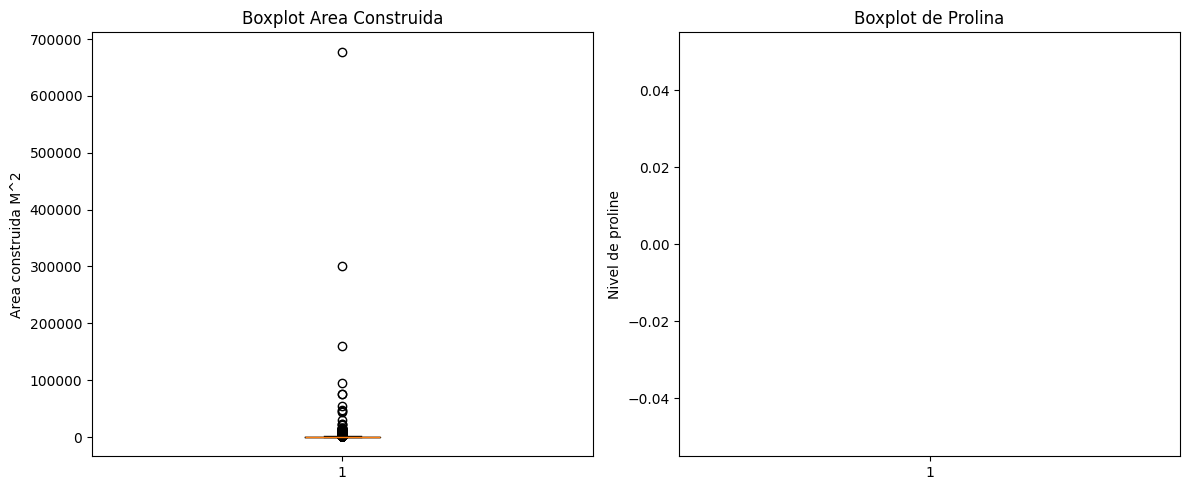

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(data_clean['Total Area'], vert=True)
axes[0].set_title("Boxplot Area Construida")
axes[0].set_ylabel("Area construida M^2")

axes[1].boxplot(data_clean['Parking'], vert=True)
axes[1].set_title("Boxplot de Prolina")
axes[1].set_ylabel("Nivel de proline")

#axes[2].boxplot(df['ash'], vert=True)
#axes[2].set_title("Boxplot de ash")
#axes[2].set_ylabel("Nivel de ash")
#
#axes[3].boxplot(df['alcalinity_of_ash'], vert=True)
#axes[3].set_title("Boxplot de alcalinity of ash")
#axes[3].set_ylabel("Nivel de alcalinity of ash")
#
#axes[4].boxplot(df['magnesium'], vert=True)
#axes[4].set_title("template")
#axes[4].set_ylabel("Nivel de alcalinity of ash")

plt.tight_layout()
plt.show()

In [ ]:
data_clean  = data[ ( data['Total Area'] > 20 ) & ( data['Total Area'] < 5000 ) & ( data['Price_UF'] > 200 )  ]
data_clean.describe().style.format("{:,.2f}")

In [ ]:
data.head()